<a href="https://colab.research.google.com/github/sacumesh/deep_learning_EuroSATSpatial/blob/sachi_train_loop/notebooks/experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install -q "torchgeo>=0.6" "transformers>=4.40"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 811.4/811.4 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 891.2/891.2 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.6/165.6 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.8/168.8 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
from __future__ import annotations

import json
import math
import platform
import random
import time
from dataclasses import asdict, dataclass, replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import transformers
import torchgeo
from sklearn.metrics import confusion_matrix, f1_score
from torch import Tensor
from torch.utils.data import DataLoader, Dataset
from torch.utils.tensorboard import SummaryWriter
from torchgeo.datamodules.eurosat import SPATIAL_MEAN, SPATIAL_STD
from torchgeo.datasets import EuroSATSpatial
from torchvision.models import ResNet50_Weights, resnet50
from torchvision.utils import make_grid
from tqdm.auto import tqdm
from transformers import AutoConfig, AutoModelForImageClassification

print(f"python {platform.python_version()} | torch {torch.__version__} | torchvision {torchvision.__version__}")
print(f"torchgeo {torchgeo.__version__} | transformers {transformers.__version__}")

python 3.13.15 | torch 2.11.0+cu130 | torchvision 0.26.0+cu130
torchgeo 0.10.0 | transformers 5.17.0


In [ ]:
@dataclass(frozen=True)
class Settings:
    """Run-wide settings (paths, hardware, reproducibility). Experiment-specific choices live in
    `ExperimentConfig` (section 4) so that the two never get mixed up."""

    data_root: Path = Path("data/eurosat")   # where torchgeo downloads / finds EuroSAT (~2 GB zip)
    runs_dir: Path = Path("runs")            # TensorBoard event files, one sub-folder per experiment
    ckpt_dir: Path = Path("checkpoints")     # best-on-validation weights, one file per experiment
    results_dir: Path = Path("results")      # json / csv summaries used in the report
    num_workers: int = 2                     # Colab has 2 CPU cores; only used while building the cache
    seed: int = 42
    smoke_test: bool = False                 # True → tiny subsets + 1 epoch, to validate the pipeline


SETTINGS = Settings()
for d in (SETTINGS.runs_dir, SETTINGS.ckpt_dir, SETTINGS.results_dir):
    d.mkdir(parents=True, exist_ok=True)


def seed_everything(seed: int) -> None:
    """Seed every RNG we rely on. Runs are then repeatable up to cuDNN's non-deterministic kernels
    (we keep `cudnn.benchmark=True` because the speed-up matters more than bit-exactness here)."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True

# Mixed precision: bf16 (Ampere and newer) needs no loss scaling; fp16 (T4) needs a GradScaler.
USE_AMP = DEVICE.type == "cuda"
AMP_DTYPE = torch.bfloat16 if (USE_AMP and torch.cuda.is_bf16_supported()) else torch.float16

seed_everything(SETTINGS.seed)
print(f"device: {DEVICE} | AMP: {USE_AMP} ({AMP_DTYPE if USE_AMP else 'fp32'}) | smoke test: {SETTINGS.smoke_test}")
if DEVICE.type == "cuda":
    print(torch.cuda.get_device_name(0))

device: cuda | AMP: True (torch.bfloat16) | smoke test: False
Tesla T4


In [ ]:
ALL_BANDS: tuple[str, ...] = tuple(EuroSATSpatial.all_band_names)  # channel order inside the GeoTIFFs
RGB_BANDS: tuple[str, ...] = tuple(EuroSATSpatial.rgb_bands)       # ('B04', 'B03', 'B02') = red, green, blue
DISPLAY_SCALE = 3000.0  # reflectance*1e4 value mapped to white when we *display* an image (ESA default)


class InMemoryEuroSAT(Dataset):
    """One EuroSAT split held in RAM as `images: int16 [N, 13, 64, 64]` and `labels: int64 [N]`.

    int16 halves the memory of float32; values above 32 767 (reflectance > 3.27) do not occur in
    cloud-free EuroSAT patches, so clamping is lossless in practice. Conversion to float happens on the GPU.
    """

    def __init__(self, images: Tensor, labels: Tensor, classes: list[str]):
        assert images.ndim == 4 and images.shape[1] == len(ALL_BANDS), images.shape
        self.images, self.labels, self.classes = images, labels, classes

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, i: int) -> tuple[Tensor, Tensor]:
        return self.images[i], self.labels[i]

    def subsample(self, n: int, seed: int) -> "InMemoryEuroSAT":
        """Random subset of `n` samples (used for the smoke test)."""
        idx = torch.randperm(len(self), generator=torch.Generator().manual_seed(seed))[:n]
        return InMemoryEuroSAT(self.images[idx], self.labels[idx], self.classes)

    @classmethod
    def from_torchgeo(cls, split: str, root: Path, num_workers: int, download: bool = True) -> "InMemoryEuroSAT":
        """Read a whole split with torchgeo once and stack it into memory (~1-2 min per split on Colab)."""
        ds = EuroSATSpatial(root=str(root), split=split, bands=ALL_BANDS, download=download)
        loader = DataLoader(ds, batch_size=256, num_workers=num_workers, shuffle=False)
        images, labels = [], []
        for batch in tqdm(loader, desc=f"caching {split}", leave=False):
            images.append(batch["image"].clamp_(0, 32767).to(torch.int16))
            labels.append(batch["label"])
        return cls(torch.cat(images), torch.cat(labels), list(ds.classes))


@dataclass
class EuroSATData:
    """The three splits plus the class names; built once and shared by all experiments."""

    train: InMemoryEuroSAT
    val: InMemoryEuroSAT
    test: InMemoryEuroSAT

    @property
    def classes(self) -> list[str]:
        return self.train.classes

    @classmethod
    def load(cls, settings: Settings) -> "EuroSATData":
        splits = {s: InMemoryEuroSAT.from_torchgeo(s, settings.data_root, settings.num_workers) for s in ("train", "val", "test")}
        if settings.smoke_test:  # tiny subsets so that every cell runs in minutes
            splits = {s: ds.subsample(512 if s == "train" else 256, settings.seed) for s, ds in splits.items()}
        return cls(**splits)


def build_dataloaders(data: EuroSATData, batch_size: int, seed: int) -> tuple[DataLoader, DataLoader, DataLoader]:
    """Data already lives in RAM, so `num_workers=0` is fastest (no inter-process copies)."""
    g = torch.Generator().manual_seed(seed)  # deterministic shuffling order per experiment
    common = dict(num_workers=0, pin_memory=DEVICE.type == "cuda")
    return (
        DataLoader(data.train, batch_size=batch_size, shuffle=True, generator=g, drop_last=True, **common),
        DataLoader(data.val, batch_size=batch_size * 2, shuffle=False, **common),
        DataLoader(data.test, batch_size=batch_size * 2, shuffle=False, **common),
    )

In [ ]:
def random_dihedral(x: Tensor) -> Tensor:
    """Random horizontal flip + random k*90° rotation, drawn independently for every sample in the batch.
    Together these generate the 8 symmetries of a square (the dihedral group D4)."""
    b = x.shape[0]
    flip = torch.rand(b, device=x.device) < 0.5
    x = torch.where(flip[:, None, None, None], x.flip(-1), x)
    k = torch.randint(0, 4, (b,), device=x.device)
    out = x.clone()
    for r in (1, 2, 3):  # k == 0 keeps the image as it is
        sel = k == r
        if sel.any():
            out[sel] = torch.rot90(x[sel], r, dims=(-2, -1))
    return out


class Preprocessor(nn.Module):
    """Batch-wise, on-device preprocessing: band selection → per-band z-score → resize → (augment).

    Living on the GPU keeps Colab's two CPU cores free and guarantees that every experiment uses exactly
    the same pipeline; only `bands` and `augment` differ between experiments.
    """

    def __init__(self, bands: tuple[str, ...], image_size: int, augment: bool):
        super().__init__()
        self.bands, self.image_size, self.augment = tuple(bands), image_size, augment
        self.register_buffer("band_idx", torch.tensor([ALL_BANDS.index(b) for b in bands]))
        self.register_buffer("mean", torch.tensor([SPATIAL_MEAN[b] for b in bands]).view(1, -1, 1, 1))
        self.register_buffer("std", torch.tensor([SPATIAL_STD[b] for b in bands]).view(1, -1, 1, 1))

    def forward(self, raw: Tensor, train: bool) -> Tensor:
        x = raw.float().index_select(1, self.band_idx)  # int16 [B,13,64,64] → float [B,C,64,64]
        x = (x - self.mean) / self.std
        if x.shape[-1] != self.image_size:
            x = F.interpolate(x, size=(self.image_size, self.image_size), mode="bilinear", align_corners=False)
        if train and self.augment:
            x = random_dihedral(x)
        return x

    def to_display_rgb(self, x: Tensor) -> Tensor:
        """Undo the z-score for the R,G,B bands of a *preprocessed* batch and map to [0,1] for viewing.
        Shows exactly what the network sees (resized, augmented) in a human-readable form."""
        pos = [self.bands.index(b) for b in RGB_BANDS]
        rgb = x[:, pos] * self.std[:, pos] + self.mean[:, pos]
        return (rgb / DISPLAY_SCALE).clamp(0, 1)


def raw_to_display_rgb(raw: Tensor) -> Tensor:
    """Raw int16 [B,13,H,W] → float RGB [B,3,H,W] in [0,1] using the standard 0–3000 stretch."""
    idx = torch.tensor([ALL_BANDS.index(b) for b in RGB_BANDS], device=raw.device)
    return (raw.float().index_select(1, idx) / DISPLAY_SCALE).clamp(0, 1)


def show_grid(images: Tensor, titles: list[str] | None = None, ncols: int = 8, size: float = 1.6, suptitle: str | None = None):
    """Small matplotlib helper: `images` is [N,3,H,W] in [0,1] (or [N,1,H,W] for a grayscale colormap)."""
    n = len(images)
    nrows = math.ceil(n / ncols)
    title_lines = max((t.count("\n") + 1 for t in titles), default=0) if titles else 0
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * size, nrows * size * (1.05 + 0.22 * title_lines)), squeeze=False)
    for k, ax in enumerate(axes.flat):
        ax.axis("off")
        if k < n:
            img = images[k].detach().cpu()
            ax.imshow(img.permute(1, 2, 0) if img.shape[0] == 3 else img[0], cmap=None if img.shape[0] == 3 else "viridis")
            if titles:
                ax.set_title(titles[k], fontsize=7)
    if suptitle:
        fig.suptitle(suptitle, fontsize=10)
    fig.tight_layout()
    return fig

In [ ]:
# Optional: persist the download across Colab sessions.
# from google.colab import drive; drive.mount("/content/drive")
# SETTINGS = replace(SETTINGS, data_root=Path("/content/drive/MyDrive/eurosat"))

DATA = EuroSATData.load(SETTINGS)
CLASS_NAMES = DATA.classes
NUM_CLASSES = len(CLASS_NAMES)

for name, split in (("train", DATA.train), ("val", DATA.val), ("test", DATA.test)):
    counts = torch.bincount(split.labels, minlength=NUM_CLASSES).tolist()
    print(f"{name:5s}: {len(split):6d} images | per class: {dict(zip(CLASS_NAMES, counts))}")
print("cache memory:", round(sum(s.images.numel() * 2 for s in (DATA.train, DATA.val, DATA.test)) / 1e9, 2), "GB")

eurosat-spatial-train.txt: 100%|██████████| 309k/309k [00:00<00:00, 15.1MB/s]
EuroSATallBands.zip: 100%|██████████| 1.93G/1.93G [00:24<00:00, 84.8MB/s]


caching train:   0%|          | 0/64 [00:00<?, ?it/s]

eurosat-spatial-val.txt: 100%|██████████| 97.4k/97.4k [00:00<00:00, 9.09MB/s]


caching val:   0%|          | 0/22 [00:00<?, ?it/s]

eurosat-spatial-test.txt: 100%|██████████| 103k/103k [00:00<00:00, 8.78MB/s]


caching test:   0%|          | 0/22 [00:00<?, ?it/s]

train:  16200 images | per class: {'AnnualCrop': 1788, 'Forest': 1309, 'HerbaceousVegetation': 1854, 'Highway': 1698, 'Industrial': 1659, 'Pasture': 1767, 'PermanentCrop': 1716, 'Residential': 1927, 'River': 1507, 'SeaLake': 975}
val  :   5400 images | per class: {'AnnualCrop': 394, 'Forest': 614, 'HerbaceousVegetation': 330, 'Highway': 462, 'Industrial': 488, 'Pasture': 118, 'PermanentCrop': 477, 'Residential': 566, 'River': 662, 'SeaLake': 1289}
test :   5400 images | per class: {'AnnualCrop': 818, 'Forest': 1077, 'HerbaceousVegetation': 816, 'Highway': 340, 'Industrial': 353, 'Pasture': 115, 'PermanentCrop': 307, 'Residential': 507, 'River': 331, 'SeaLake': 736}
cache memory: 2.88 GB


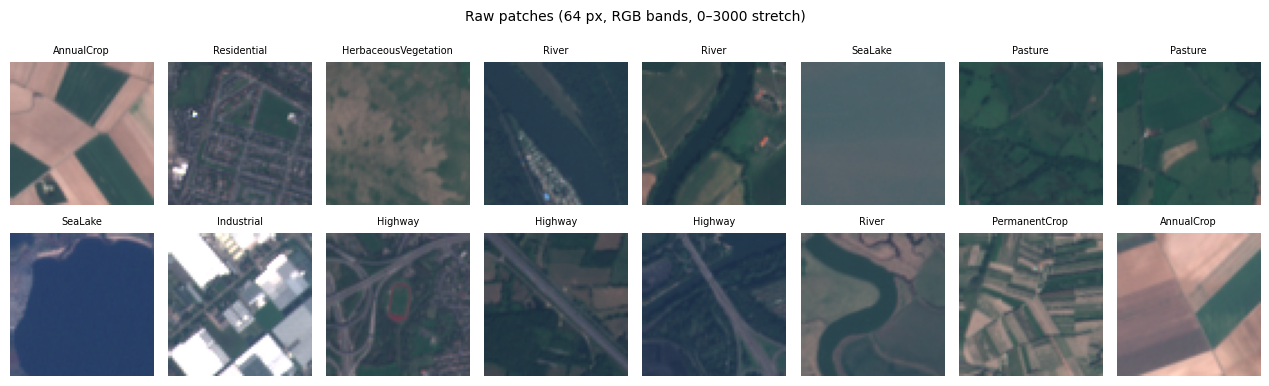

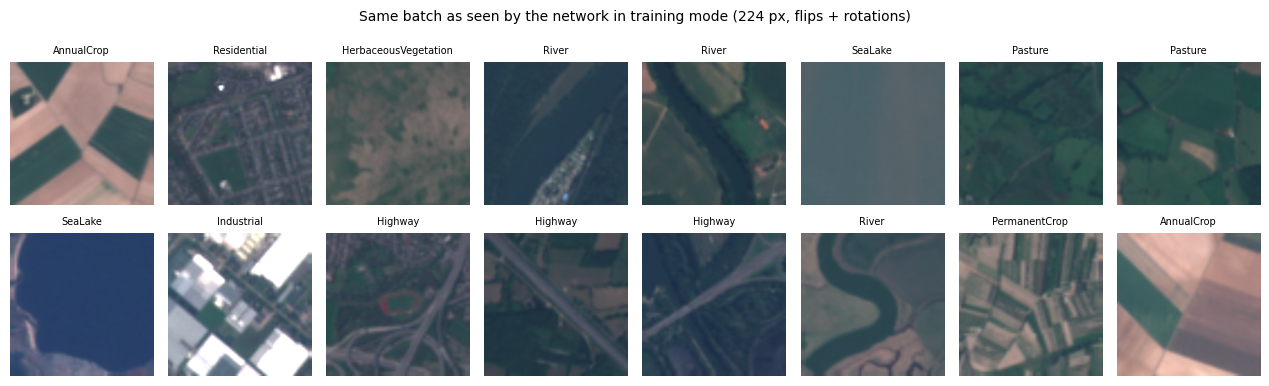

In [ ]:
raw, labels = next(iter(build_dataloaders(DATA, batch_size=16, seed=0)[0]))
raw = raw.to(DEVICE)
titles = [CLASS_NAMES[i] for i in labels]

show_grid(raw_to_display_rgb(raw), titles, suptitle="Raw patches (64 px, RGB bands, 0–3000 stretch)")
prep_aug = Preprocessor(RGB_BANDS, image_size=224, augment=True).to(DEVICE)
show_grid(prep_aug.to_display_rgb(prep_aug(raw, train=True)), titles,
          suptitle="Same batch as seen by the network in training mode (224 px, flips + rotations)")
plt.show()

In [ ]:
def adapt_first_conv(conv: nn.Conv2d, bands: tuple[str, ...]) -> nn.Conv2d:
    """Inflate a pre-trained RGB convolution so that it accepts `len(bands)` input channels.

    R/G/B bands reuse their exact ImageNet filter, other bands get the mean RGB filter, and all weights are
    scaled by 3/len(bands) to keep the expected pre-activation magnitude unchanged.
    """
    if tuple(bands) == RGB_BANDS:
        return conv  # nothing to do, torchvision's conv expects R,G,B in this order
    new = nn.Conv2d(len(bands), conv.out_channels, conv.kernel_size, conv.stride, conv.padding, bias=conv.bias is not None)
    with torch.no_grad():
        w = conv.weight  # [out, 3, k, k] in R, G, B order
        rgb_pos = dict(zip(RGB_BANDS, range(3)))
        mean_filter = w.mean(dim=1)
        new.weight.copy_(torch.stack([w[:, rgb_pos[b]] if b in rgb_pos else mean_filter for b in bands], dim=1) * (3 / len(bands)))
        if conv.bias is not None:
            new.bias.copy_(conv.bias)
    return new


def build_resnet50(bands: tuple[str, ...], num_classes: int, pretrained: bool) -> nn.Module:
    model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2 if pretrained else None)
    model.conv1 = adapt_first_conv(model.conv1, bands)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


class HFImageClassifier(nn.Module):
    """Wraps a Hugging Face image classifier so that it behaves like a torchvision model: `forward(x) -> logits`.
    `attn_implementation="eager"` is required to read the attention maps back later (section 8)."""

    def __init__(self, model_id: str, num_classes: int, pretrained: bool):
        super().__init__()
        if pretrained:  # the 1000-way ImageNet head is dropped and a fresh `num_classes` head is created
            self.net = AutoModelForImageClassification.from_pretrained(model_id, num_labels=num_classes, ignore_mismatched_sizes=True, attn_implementation="eager")
        else:
            self.net = AutoModelForImageClassification.from_config(AutoConfig.from_pretrained(model_id, num_labels=num_classes), attn_implementation="eager")
        self.native_size = self.net.config.image_size

    def _call(self, x: Tensor, **kw):
        # position embeddings are learned for `native_size`; interpolate them for any other input size
        return self.net(pixel_values=x, interpolate_pos_encoding=x.shape[-1] != self.native_size, **kw)

    def forward(self, x: Tensor) -> Tensor:
        return self._call(x).logits

    def forward_with_attention(self, x: Tensor) -> tuple[Tensor, tuple[Tensor, ...]]:
        out = self._call(x, output_attentions=True)
        return out.logits, out.attentions

    @property
    def head(self) -> nn.Module:
        return self.net.classifier


def classifier_head(model: nn.Module) -> nn.Module:
    return model.head if isinstance(model, HFImageClassifier) else model.fc


def set_train_mode(model: nn.Module, freeze_backbone: bool) -> None:
    """`model.train()`, except that a frozen backbone keeps its BatchNorm statistics frozen too."""
    model.train()
    if freeze_backbone:
        for m in model.modules():
            if isinstance(m, nn.modules.batchnorm._BatchNorm):
                m.eval()


def count_parameters(model: nn.Module) -> tuple[int, int]:
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

In [ ]:
@dataclass
class ExperimentConfig:
    """Everything that can differ between two runs. Defaults = the baseline E1."""

    name: str
    description: str = ""
    model: str = "resnet50"                                # "resnet50" | "vit"
    hf_model_id: str = "facebook/deit-small-patch16-224"   # only used when model == "vit"
    bands: tuple[str, ...] = RGB_BANDS
    pretrained: bool = True
    freeze_backbone: bool = False
    augment: bool = False
    image_size: int = 224
    epochs: int = 8
    batch_size: int = 64
    lr: float = 1e-4
    weight_decay: float = 0.05
    warmup_epochs: float = 1.0
    grad_clip: float = 1.0
    seed: int = SETTINGS.seed

    def hparams(self) -> dict:
        """Flat, TensorBoard-compatible view (only int / float / str / bool)."""
        d = asdict(self)
        d["bands"] = "+".join(self.bands) if len(self.bands) <= 3 else f"all{len(self.bands)}"
        return d


def build_model(cfg: ExperimentConfig, num_classes: int) -> nn.Module:
    if cfg.model == "resnet50":
        model = build_resnet50(cfg.bands, num_classes, cfg.pretrained)
    elif cfg.model == "vit":
        assert tuple(cfg.bands) == RGB_BANDS, "the ViT experiment is RGB-only (pre-trained patch embedding has 3 channels)"
        model = HFImageClassifier(cfg.hf_model_id, num_classes, cfg.pretrained)
    else:
        raise ValueError(f"unknown model {cfg.model!r}")
    if cfg.freeze_backbone:
        for p in model.parameters():
            p.requires_grad = False
        for p in classifier_head(model).parameters():
            p.requires_grad = True
    return model


def build_optimizer(model: nn.Module, cfg: ExperimentConfig) -> torch.optim.Optimizer:
    """AdamW with weight decay only on weight matrices / kernels (not on biases and norm layers)."""
    decay, no_decay = [], []
    for p in model.parameters():
        if p.requires_grad:
            (decay if p.ndim > 1 else no_decay).append(p)
    return torch.optim.AdamW([{"params": decay, "weight_decay": cfg.weight_decay}, {"params": no_decay, "weight_decay": 0.0}], lr=cfg.lr)


def build_scheduler(optimizer: torch.optim.Optimizer, cfg: ExperimentConfig, steps_per_epoch: int):
    """Linear warm-up followed by cosine decay, updated every optimisation step."""
    total, warmup = cfg.epochs * steps_per_epoch, max(1, int(cfg.warmup_epochs * steps_per_epoch))

    def lr_factor(step: int) -> float:
        if step < warmup:
            return (step + 1) / warmup
        progress = (step - warmup) / max(1, total - warmup)
        return 0.5 * (1.0 + math.cos(math.pi * min(progress, 1.0)))

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_factor)


def train_one_epoch(model, preprocess, loader, criterion, optimizer, scheduler, scaler, cfg, writer, global_step: int) -> tuple[dict, int]:
    set_train_mode(model, cfg.freeze_backbone)
    loss_sum, correct, seen, t0 = 0.0, 0, 0, time.time()
    for raw, target in loader:
        raw, target = raw.to(DEVICE, non_blocking=True), target.to(DEVICE, non_blocking=True)
        with torch.no_grad():
            x = preprocess(raw, train=True)
        with torch.autocast(DEVICE.type, dtype=AMP_DTYPE, enabled=USE_AMP):
            logits = model(x)
            loss = criterion(logits, target)
        optimizer.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)  # gradients must be un-scaled before clipping
        nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        writer.add_scalar("train/loss_step", loss.item(), global_step)
        writer.add_scalar("train/lr", scheduler.get_last_lr()[0], global_step)
        loss_sum += loss.item() * len(target)
        correct += (logits.argmax(1) == target).sum().item()
        seen += len(target)
        global_step += 1
    elapsed = time.time() - t0
    return {"loss": loss_sum / seen, "acc": correct / seen, "time_s": elapsed, "img_per_s": seen / elapsed}, global_step


@torch.no_grad()
def evaluate(model, preprocess, loader, criterion) -> dict:
    model.eval()
    loss_sum, preds, targets = 0.0, [], []
    for raw, target in loader:
        x = preprocess(raw.to(DEVICE, non_blocking=True), train=False)
        with torch.autocast(DEVICE.type, dtype=AMP_DTYPE, enabled=USE_AMP):
            logits = model(x)
        loss_sum += criterion(logits.float(), target.to(DEVICE)).item() * len(target)
        preds.append(logits.argmax(1).cpu())
        targets.append(target)
    preds, targets = torch.cat(preds).numpy(), torch.cat(targets).numpy()
    return {
        "loss": loss_sum / len(targets),
        "acc": float((preds == targets).mean()),
        "macro_f1": float(f1_score(targets, preds, average="macro")),
        "preds": preds,
        "targets": targets,
    }

In [ ]:
def confusion_matrix_figure(targets: np.ndarray, preds: np.ndarray, classes: list[str], title: str):
    cm = confusion_matrix(targets, preds, labels=range(len(classes)))
    cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set(xticks=range(len(classes)), yticks=range(len(classes)), xlabel="predicted", ylabel="true", title=title)
    ax.set_xticklabels(classes, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(classes, fontsize=8)
    for i in range(len(classes)):
        for j in range(len(classes)):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=6, color="white" if cm_norm[i, j] > 0.5 else "black")
    fig.colorbar(im, ax=ax, fraction=0.046)
    fig.tight_layout()
    return fig, cm


def misclassified_figure(raw_images: Tensor, targets: np.ndarray, preds: np.ndarray, classes: list[str], n: int = 16):
    wrong = np.flatnonzero(preds != targets)[:n]
    if len(wrong) == 0:
        return None
    titles = [f"true: {classes[targets[i]]}\npred: {classes[preds[i]]}" for i in wrong]
    return show_grid(raw_to_display_rgb(raw_images[wrong]), titles, ncols=8, size=1.7, suptitle="Mis-classified test images")


def log_input_batch(writer: SummaryWriter, preprocess: Preprocessor, raw: Tensor) -> None:
    """Log the raw batch and the exact (augmented) tensors the model receives, as image grids."""
    raw = raw[:32].to(DEVICE)
    writer.add_image("inputs/raw_rgb", make_grid(raw_to_display_rgb(raw), nrow=8), 0)
    writer.add_image("inputs/as_seen_by_model", make_grid(preprocess.to_display_rgb(preprocess(raw, train=True)), nrow=8), 0)


def run_experiment(cfg: ExperimentConfig, data: EuroSATData, evaluate_test: bool = True) -> dict:
    """Train `cfg` from scratch, keep the best-on-validation weights, evaluate them on the test set once."""
    if SETTINGS.smoke_test:
        cfg = replace(cfg, epochs=1, warmup_epochs=0.2)
    seed_everything(cfg.seed)
    writer = SummaryWriter(str(SETTINGS.runs_dir / cfg.name))
    train_loader, val_loader, test_loader = build_dataloaders(data, cfg.batch_size, cfg.seed)
    preprocess = Preprocessor(cfg.bands, cfg.image_size, cfg.augment).to(DEVICE)
    model = build_model(cfg, len(data.classes)).to(DEVICE)
    n_total, n_trainable = count_parameters(model)
    criterion = nn.CrossEntropyLoss()
    optimizer = build_optimizer(model, cfg)
    scheduler = build_scheduler(optimizer, cfg, len(train_loader))
    scaler = torch.amp.GradScaler(DEVICE.type, enabled=USE_AMP and AMP_DTYPE == torch.float16)
    log_input_batch(writer, preprocess, next(iter(train_loader))[0])

    print(f"\n=== {cfg.name}: {cfg.description}\n    params: {n_total / 1e6:.1f} M total, {n_trainable / 1e6:.2f} M trainable | {cfg.epochs} epochs | lr {cfg.lr:g}")
    ckpt_path = SETTINGS.ckpt_dir / f"{cfg.name}.pt"
    history, best_val_acc, best_epoch, global_step, t_start = [], -1.0, -1, 0, time.time()
    for epoch in range(cfg.epochs):
        train_stats, global_step = train_one_epoch(model, preprocess, train_loader, criterion, optimizer, scheduler, scaler, cfg, writer, global_step)
        val_stats = evaluate(model, preprocess, val_loader, criterion)
        for k in ("loss", "acc"):
            writer.add_scalar(f"train/{k}", train_stats[k], epoch)
            writer.add_scalar(f"val/{k}", val_stats[k], epoch)
        writer.add_scalar("val/macro_f1", val_stats["macro_f1"], epoch)
        writer.add_scalar("train/img_per_s", train_stats["img_per_s"], epoch)
        history.append({"epoch": epoch, "train_loss": train_stats["loss"], "train_acc": train_stats["acc"],
                        "val_loss": val_stats["loss"], "val_acc": val_stats["acc"], "val_macro_f1": val_stats["macro_f1"]})
        if val_stats["acc"] > best_val_acc:
            best_val_acc, best_epoch = val_stats["acc"], epoch
            torch.save(model.state_dict(), ckpt_path)
        print(f"    epoch {epoch + 1:2d}/{cfg.epochs} | train loss {train_stats['loss']:.3f} acc {train_stats['acc']:.3f} "
              f"| val loss {val_stats['loss']:.3f} acc {val_stats['acc']:.3f} f1 {val_stats['macro_f1']:.3f} "
              f"| {train_stats['img_per_s']:.0f} img/s")

    result = {"name": cfg.name, "description": cfg.description, "params_total_M": round(n_total / 1e6, 2),
              "params_trainable_M": round(n_trainable / 1e6, 3), "best_epoch": best_epoch + 1, "best_val_acc": best_val_acc,
              "train_time_min": round((time.time() - t_start) / 60, 1), "history": history, "config": cfg.hparams()}
    if evaluate_test:
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))  # best-on-validation weights
        test_stats = evaluate(model, preprocess, test_loader, criterion)
        fig_cm, cm = confusion_matrix_figure(test_stats["targets"], test_stats["preds"], data.classes, f"{cfg.name} — test confusion matrix")
        writer.add_figure("test/confusion_matrix", fig_cm, 0)
        fig_wrong = misclassified_figure(data.test.images, test_stats["targets"], test_stats["preds"], data.classes)
        if fig_wrong is not None:
            writer.add_figure("test/misclassified", fig_wrong, 0)
        plt.close("all")
        result.update({"test_acc": test_stats["acc"], "test_macro_f1": test_stats["macro_f1"],
                       "per_class_acc": dict(zip(data.classes, (np.diag(cm) / cm.sum(axis=1).clip(min=1)).round(4).tolist()))})
        writer.add_hparams(cfg.hparams(), {"hparam/test_acc": test_stats["acc"], "hparam/test_macro_f1": test_stats["macro_f1"], "hparam/best_val_acc": best_val_acc})
        print(f"    TEST (best val epoch {best_epoch + 1}): acc {test_stats['acc']:.4f} | macro-F1 {test_stats['macro_f1']:.4f}")
    writer.close()
    (SETTINGS.results_dir / f"{cfg.name}.json").write_text(json.dumps(result, indent=2))
    return result

In [ ]:
RUN_LR_SWEEP = True
SWEEP_LRS = (3e-5, 1e-4, 3e-4)

BASE = ExperimentConfig(name="E1_baseline", description="ResNet-50, RGB, ImageNet init, full fine-tuning, no augmentation")

if RUN_LR_SWEEP:
    sweep_rows = []
    for lr in SWEEP_LRS:
        res = run_experiment(replace(BASE, name=f"sweep_lr_{lr:g}", description=f"LR sweep, lr={lr:g}", lr=lr, epochs=2, warmup_epochs=0.5), DATA, evaluate_test=False)
        sweep_rows.append({"lr": lr, "best_val_acc": res["best_val_acc"], "final_train_loss": res["history"][-1]["train_loss"]})
    sweep_df = pd.DataFrame(sweep_rows)
    display(sweep_df)
    BEST_LR = float(sweep_df.loc[sweep_df.best_val_acc.idxmax(), "lr"])
else:
    BEST_LR = 1e-4
print(f"selected learning rate: {BEST_LR:g}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 171MB/s]



=== sweep_lr_3e-05: LR sweep, lr=3e-05
    params: 23.5 M total, 23.53 M trainable | 2 epochs | lr 3e-05
    epoch  1/2 | train loss 1.276 acc 0.648 | val loss 0.223 acc 0.938 f1 0.917 | 43 img/s
    epoch  2/2 | train loss 0.136 acc 0.961 | val loss 0.172 acc 0.949 f1 0.926 | 43 img/s

=== sweep_lr_0.0001: LR sweep, lr=0.0001
    params: 23.5 M total, 23.53 M trainable | 2 epochs | lr 0.0001
    epoch  1/2 | train loss 0.763 acc 0.783 | val loss 0.176 acc 0.944 f1 0.926 | 43 img/s
    epoch  2/2 | train loss 0.061 acc 0.979 | val loss 0.112 acc 0.966 f1 0.950 | 43 img/s

=== sweep_lr_0.0003: LR sweep, lr=0.0003
    params: 23.5 M total, 23.53 M trainable | 2 epochs | lr 0.0003
    epoch  1/2 | train loss 0.549 acc 0.842 | val loss 0.236 acc 0.922 f1 0.885 | 43 img/s
    epoch  2/2 | train loss 0.057 acc 0.982 | val loss 0.103 acc 0.969 f1 0.955 | 43 img/s


,lr,best_val_acc,final_train_loss
0,0.00003,0.948704,0.135741
1,0.00010,0.966111,0.061394
2,0.00030,0.969444,0.056883


selected learning rate: 0.0003


In [ ]:
EXPERIMENTS = [
    replace(BASE, lr=BEST_LR),
    ExperimentConfig(
        name="E2_linear_probe", freeze_backbone=True, lr=10 * BEST_LR,
        description="E1 with a frozen backbone (classifier only). Hypothesis: ImageNet features are useful "
                    "but not sufficient for satellite data, so this should stay clearly below E1."),
    ExperimentConfig(
        name="E3_augmentation", augment=True, lr=BEST_LR,
        description="E1 + flips / 90-degree rotations. Hypothesis: satellite patches have no canonical orientation, "
                    "so the augmentation should reduce over-fitting and improve validation/test accuracy."),
    ExperimentConfig(
        name="E4_multispectral", bands=ALL_BANDS, augment=True, lr=BEST_LR,
        description="E3 with all 13 Sentinel-2 bands (inflated first conv). Hypothesis: NIR/SWIR bands separate "
                    "vegetation, water and built-up areas better than RGB, helping the confusable classes "
                    "(Highway/River, PermanentCrop/HerbaceousVegetation)."),
    ExperimentConfig(
        name="E5_vit", model="vit", augment=True, lr=BEST_LR,
        description="DeiT-Small (22M params, ImageNet-1k) under the E3 recipe. Question: does a Transformer beat a CNN of similar "
                    "size on small (64 px, up-sampled) satellite patches, or does the CNN's locality prior win?"),
    # Optional extra (≈10 min): the same network trained from random init, to quantify the value of pre-training.
    # ExperimentConfig(name="E6_scratch", pretrained=False, augment=True, lr=1e-3, description="E3 from random initialisation"),
]

In [ ]:
RESULTS = []
for cfg in EXPERIMENTS:
    RESULTS.append(run_experiment(cfg, DATA))


=== E1_baseline: ResNet-50, RGB, ImageNet init, full fine-tuning, no augmentation
    params: 23.5 M total, 23.53 M trainable | 8 epochs | lr 0.0003
    epoch  1/8 | train loss 0.673 acc 0.807 | val loss 0.295 acc 0.908 f1 0.879 | 43 img/s
    epoch  2/8 | train loss 0.126 acc 0.961 | val loss 0.138 acc 0.959 f1 0.939 | 43 img/s
    epoch  3/8 | train loss 0.060 acc 0.981 | val loss 0.156 acc 0.953 f1 0.937 | 43 img/s
    epoch  4/8 | train loss 0.032 acc 0.990 | val loss 0.131 acc 0.963 f1 0.947 | 43 img/s
    epoch  5/8 | train loss 0.015 acc 0.996 | val loss 0.111 acc 0.970 f1 0.958 | 43 img/s
    epoch  6/8 | train loss 0.006 acc 0.998 | val loss 0.089 acc 0.974 f1 0.962 | 43 img/s
    epoch  7/8 | train loss 0.002 acc 1.000 | val loss 0.096 acc 0.973 f1 0.959 | 43 img/s
    epoch  8/8 | train loss 0.001 acc 1.000 | val loss 0.103 acc 0.972 f1 0.956 | 43 img/s
    TEST (best val epoch 6): acc 0.9583 | macro-F1 0.9343

=== E2_linear_probe: E1 with a frozen backbone (classifier only

In [ ]:
SUMMARY_COLS = ["name", "params_total_M", "params_trainable_M", "best_epoch", "best_val_acc", "test_acc", "test_macro_f1", "train_time_min"]
summary = pd.DataFrame([{k: r[k] for k in SUMMARY_COLS} for r in RESULTS]).set_index("name")
summary.to_csv(SETTINGS.results_dir / "summary.csv")
display(summary.style.format({"best_val_acc": "{:.4f}", "test_acc": "{:.4f}", "test_macro_f1": "{:.4f}"}).highlight_max(subset=["test_acc", "test_macro_f1"], color="#c6efce"))

per_class = pd.DataFrame({r["name"]: r["per_class_acc"] for r in RESULTS}).T
per_class.to_csv(SETTINGS.results_dir / "per_class_accuracy.csv")
display(per_class.style.format("{:.3f}").background_gradient(cmap="RdYlGn", axis=None, vmin=0.7, vmax=1.0))

NameError: name 'RESULTS' is not defined

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for r in RESULTS:
    h = pd.DataFrame(r["history"])
    axes[0].plot(h.epoch + 1, h.train_loss, marker="o", ms=3, label=r["name"])
    axes[1].plot(h.epoch + 1, h.val_acc, marker="o", ms=3, label=r["name"])
axes[0].set(title="training loss", xlabel="epoch", ylabel="cross-entropy")
axes[1].set(title="validation accuracy", xlabel="epoch", ylabel="accuracy")
axes[1].legend(fontsize=8)
x = np.arange(len(summary))
axes[2].bar(x - 0.2, summary.test_acc, width=0.4, label="test accuracy")
axes[2].bar(x + 0.2, summary.test_macro_f1, width=0.4, label="test macro-F1")
axes[2].set(title="test set (best-on-validation checkpoint)", xticks=x, ylim=(max(0.0, summary[["test_acc", "test_macro_f1"]].min().min() - 0.05), 1.0))
axes[2].set_xticklabels(summary.index, rotation=25, ha="right", fontsize=8)
axes[2].legend(fontsize=8)
for xi, v in zip(x, summary.test_acc):
    axes[2].text(xi - 0.2, v + 0.003, f"{v:.3f}", ha="center", fontsize=7)
fig.tight_layout()
fig.savefig(SETTINGS.results_dir / "curves_and_test.png", dpi=150)
plt.show()

In [ ]:
class FeatureMapRecorder:
    """Context manager: registers forward hooks on the named sub-modules and stores their outputs."""

    def __init__(self, model: nn.Module, layer_names: list[str]):
        self.modules = dict(model.named_modules())
        self.layer_names, self.outputs, self._handles = layer_names, {}, []

    def __enter__(self):
        for name in self.layer_names:
            self._handles.append(self.modules[name].register_forward_hook(lambda m, i, o, name=name: self.outputs.__setitem__(name, o.detach().float().cpu())))
        return self

    def __exit__(self, *exc):
        for h in self._handles:
            h.remove()


def load_experiment_model(name: str, data: EuroSATData) -> tuple[ExperimentConfig, nn.Module, Preprocessor]:
    """Rebuild model + preprocessor of a finished experiment and load its best checkpoint."""
    cfg = next(c for c in EXPERIMENTS if c.name == name)
    model = build_model(cfg, len(data.classes)).to(DEVICE)
    model.load_state_dict(torch.load(SETTINGS.ckpt_dir / f"{name}.pt", map_location=DEVICE))
    model.eval()
    return cfg, model, Preprocessor(cfg.bands, cfg.image_size, cfg.augment).to(DEVICE)


def channel_grid(fmap: Tensor, max_channels: int = 16) -> Tensor:
    """[1, C, H, W] → grid image [1, gh, gw] of the first `max_channels` channels, each min-max scaled."""
    maps = fmap[0, :max_channels].unsqueeze(1)  # [c, 1, H, W]
    lo = maps.amin(dim=(2, 3), keepdim=True)
    hi = maps.amax(dim=(2, 3), keepdim=True)
    return make_grid((maps - lo) / (hi - lo + 1e-6), nrow=8, padding=1, pad_value=0.0)[:1]


RESNET_STAGES = ["conv1", "layer1", "layer2", "layer3", "layer4"]


@torch.no_grad()
def visualize_cnn_layers(exp_name: str, data: EuroSATData, sample_idx: int, writer: SummaryWriter, max_channels: int = 16):
    cfg, model, preprocess = load_experiment_model(exp_name, data)
    raw, label = data.test[sample_idx]
    raw = raw.unsqueeze(0).to(DEVICE)
    with FeatureMapRecorder(model, RESNET_STAGES) as rec:
        pred = model(preprocess(raw, train=False)).argmax(1).item()
    title = f"{exp_name} | true: {data.classes[label]} | predicted: {data.classes[pred]}"

    fig, axes = plt.subplots(len(RESNET_STAGES) + 1, 1, figsize=(10, 2.6 * (len(RESNET_STAGES) + 1)))
    axes[0].imshow(raw_to_display_rgb(raw)[0].permute(1, 2, 0).cpu())
    axes[0].set_title(title, fontsize=10)
    axes[0].axis("off")
    for ax, name in zip(axes[1:], RESNET_STAGES):
        fmap = rec.outputs[name]
        grid = channel_grid(fmap, max_channels)
        ax.imshow(grid[0], cmap="viridis")
        ax.set_title(f"{name}: {fmap.shape[1]} channels × {fmap.shape[2]}×{fmap.shape[3]} (first {min(max_channels, fmap.shape[1])} shown)", fontsize=9)
        ax.axis("off")
        writer.add_image(f"{exp_name}/feature_maps/{name}", grid, sample_idx)
    fig.tight_layout()
    writer.add_figure(f"{exp_name}/feature_maps/overview", fig, sample_idx)
    return fig


@torch.no_grad()
def visualize_first_conv(exp_name: str, data: EuroSATData, writer: SummaryWriter):
    """First-layer filters (RGB view) and, for multispectral models, the weight each band receives."""
    cfg, model, _ = load_experiment_model(exp_name, data)
    w = model.conv1.weight.detach().float().cpu()  # [64, C, 7, 7]
    rgb_pos = [cfg.bands.index(b) for b in RGB_BANDS]
    filters = w[:, rgb_pos]
    lo, hi = filters.amin(dim=(1, 2, 3), keepdim=True), filters.amax(dim=(1, 2, 3), keepdim=True)
    grid = make_grid((filters - lo) / (hi - lo + 1e-6), nrow=16, padding=1, pad_value=1.0)
    writer.add_image(f"{exp_name}/conv1_filters_rgb", grid, 0)

    ncols = 2 if len(cfg.bands) > 3 else 1
    fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols + 2, 3.2), squeeze=False)
    axes[0, 0].imshow(grid.permute(1, 2, 0))
    axes[0, 0].set_title(f"{exp_name}: conv1 filters (R,G,B input channels of the 7×7 kernels)", fontsize=9)
    axes[0, 0].axis("off")
    if len(cfg.bands) > 3:
        band_weight = w.abs().mean(dim=(0, 2, 3))  # mean |w| per input band → how much conv1 listens to each band
        axes[0, 1].bar(cfg.bands, band_weight, color=["tab:red" if b == "B04" else "tab:green" if b == "B03" else "tab:blue" if b == "B02" else "gray" for b in cfg.bands])
        axes[0, 1].set_title("mean |weight| of conv1 per input band (after fine-tuning)", fontsize=9)
        axes[0, 1].tick_params(axis="x", labelrotation=45, labelsize=8)
        writer.add_figure(f"{exp_name}/conv1_band_importance", fig, 0)
    fig.tight_layout()
    return fig

In [ ]:
@torch.no_grad()
def visualize_vit_attention(exp_name: str, data: EuroSATData, sample_idx: int, writer: SummaryWriter):
    cfg, model, preprocess = load_experiment_model(exp_name, data)
    raw, label = data.test[sample_idx]
    raw = raw.unsqueeze(0).to(DEVICE)
    logits, attentions = model.forward_with_attention(preprocess(raw, train=False))
    attn = attentions[-1][0].float().cpu()      # last layer: [heads, 1 + N, 1 + N]
    cls_attn = attn[:, 0, 1:]                   # attention of [CLS] to the N patches: [heads, N]
    g = int(math.sqrt(cls_attn.shape[1]))
    heads = cls_attn.reshape(-1, g, g)
    mean_map = F.interpolate(heads.mean(0)[None, None], size=(64, 64), mode="bilinear", align_corners=False)[0, 0]

    fig, axes = plt.subplots(1, 2 + heads.shape[0], figsize=(2.2 * (2 + heads.shape[0]), 2.6))
    img = raw_to_display_rgb(raw)[0].permute(1, 2, 0).cpu()
    axes[0].imshow(img)
    axes[0].set_title(f"true: {data.classes[label]}\npred: {data.classes[logits.argmax(1).item()]}", fontsize=8)
    axes[1].imshow(img)
    axes[1].imshow(mean_map, cmap="jet", alpha=0.5)
    axes[1].set_title("[CLS] attention, mean of heads", fontsize=8)
    for h, ax in enumerate(axes[2:]):
        ax.imshow(heads[h], cmap="viridis")
        ax.set_title(f"head {h}", fontsize=8)
    for ax in axes:
        ax.axis("off")
    fig.tight_layout()
    writer.add_figure(f"{exp_name}/cls_attention", fig, sample_idx)
    return fig


if any(r["name"] == "E5_vit" for r in RESULTS):
    visualize_vit_attention("E5_vit", DATA, SAMPLE_IDX, VIZ_WRITER)
    plt.show()
VIZ_WRITER.close()